## 1. Introduction:  Using Large Language Models to Analyze Music as MEI and JSON

### Some Research Questions and Challenges  



In this notebook, we will be using LangChain and OpenAI to evaluate a Large Language Model's (LLM's) ability to analyze music. To do this, we will be exploring the LLM's capabilities by touching on each of the following concepts:

* **Work with metadata in the MEI files.**  Tell us something about which ones are most similar in terms of sources, editors, composers.  The LLM also produce a structured output, like a database of pieces based on metadata in them?  

* **Get Tabular Summaries of Features from MEI (Music Encoding Initiative).**  Music21 can read MEI files and find attributes like notes or intervals.  Can the LLM summarize this information in a table?  Can it find patterns in the data?  Can it find pieces that are similar in terms of pitch content?  Can it find pieces that are similar in terms of interval content? 

* **Guess the Key of a Piece.**  Using built-in music21 functionality, we can return the key and a confidence factor.  Surely without tools, the LLM would do this rather differently!

* **Get Lyrics from MEI and Recreate It.**  Lyrics are also elements in MEI (and MusicXML)  of course they are distributed among different vocal lines in the case of Renaissance music, and there are lots of word repetitions.  Could we recover the text and then use LLM to put into shape (as a rhymed poem, or something like that?).  Could they LLM use the placement of rests as a way to understand the form?  What *tools* might help the LLM do this?  Could it do it without tools?

* **Rank Pieces by Difficulty.**  Things with lots of changes of direction, or wide leaps, or difficult rhythms, etc.  The Bartok pieces are in fact pedagogical (and even in order).   What would our LLM *presume* about the difficulty of these pieces?  Could it rank them in order of difficulty?  Could it do this with and without tools?
 

#### Sample MEI Files
During these tests, we are using a sample of about 30 mei files:

* Morley, Canzonets for Two Voices (1595)
* Bach, Two-Part Inventions (BWV 772-786)
* Bartok, Mikrokosmos (Canonic Compositions, from Books 1-6)   

#### With and Without Tools

For the **LLM with tools**, we feed the LLM a basic dictionary with the title, composer, filepath, and number of parts. From here we let the LLM select a 'tool' based on its reading of the natural language prompt that the user provides.  The LLM does not see the Music21 methods or the MEI files themselves, but it can use the tools to get information from the MEI files.  The LLM can then use this information to answer questions about the music.  The LLM can also use the tools to get information about the music that is not in the MEI files, such as the key of a piece or the difficulty of a piece.

For the **LLM without tools**, we saved *extended summary information about the musical features as a JSON file*. This JSON includes **basic metadata**, as well as **all of the pitches and intervals for each part, and the key**. Without this information we can be sure that the LLM would fail, since the XML-structure of the MEI files is too large for the LLM to process directly. But even with these JSON summaries, the reliability of the results is limited, since the LLM is working with the pitches and intervals as text strings. 

All of the LLM music analysis in this experiment uses **gpt-4o by OpenAI**.

## 2. Setup Code

This section builds everything the experiment needs before we ask the LLM anything:

A. **Imports**.  These are the libraries for parsing music (`music21`), reading MEI/XML directly, and orchestrating the LLM (`langchain`/`langgraph`).


B. **Two parallel data representations** of the same 9 pieces:

The first of these dictionaries is for use *with tools*, and contains only basic metadata about each piece, including the filepath, composer, title, and count of parts.  When the LLM sees `use_tools=True`, it must call a tool answer our questions about pitches, intervals and keys.  

   - `metadata_summaries.json` — a *lightweight pointer dict* consisting of only basic metadata about each piece in our list of MEI Files:  (title, composer, filepath, part count). This is what the `use_tools=True` condition sees; the LLM must call a tool to actually open the file and compute anything.

The second of these is for use *without tools*, and contains a rich summary of every pitch, interval, and key signature in each piece.  Why?  Because if the LLM were to attempt to read our MEI (XML) directly, the context would be too large to process effectively. Our `music_feature_summaries` dictionaries are precomputed to avoid this issue, providing a more manageable dataset for the LLM to analyze.  But since it must reason over this data itself, with no way to verify its own arithmetic.

   - `music_feature_summaries.json` — a *rich, precomputed* dict already containing every pitch, interval, time/key signature. This is what the `use_tools=False` condition sees; the LLM only reads numbers as text and must reason over them itself, with no way to verify its own arithmetic.

We also load the MEI files themselves into a list of `Document` objects, which is not used in this notebook, but could be used to give the LLM the full XML if desired.  These are saved together as `full_mei` in the code below.



C. **Tools** — `music21`-backed functions exposed to the LLM via LangChain's `@tool` decorator, used only in the `use_tools=True` condition.

D. **The LangGraph state machine** that wires a question + these data sources into a single `run_graph()` call, branching on `use_tools`.

Keeping these two data sources and the tool-calling loop cleanly separated is what makes the later "with tools vs. without tools" comparison meaningful.

#### A. Imports

Standard library modules for file/XML handling, `pandas`/`music21` for reading and analyzing the scores, and the LangChain/LangGraph pieces we'll use to: define tools (`tool`), build prompts (`ChatPromptTemplate`), talk to OpenAI (`ChatOpenAI`), and wire everything into a small state graph (`StateGraph`).

In [1]:
# Standard library imports
import ast
import getpass
import json
import os
import re
from collections import Counter
from pathlib import Path
from typing import List, Optional, Union
from typing_extensions import TypedDict
import xml.etree.ElementTree as ET

# m21 and pandas imports
import pandas as pd
from music21 import converter, metadata, note, interval

# LangChain imports
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document
from langchain_core.messages import ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool                          # moved from langchain.tools
from langchain_community.document_loaders import TextLoader
from langchain_experimental.tools.python.tool import PythonREPLTool
from langgraph.graph import START, StateGraph

/Users/rfreedma/anaconda3/envs/lang/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/Users/rfreedma/anaconda3/envs/lang/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Sanity check, not part of the experiment.** This cell parses the raw MEI/XML directly with `xml.etree.ElementTree` — no `music21`, no LLM — just to confirm the titles and composers are readable in every sample file before we build anything on top of them.

In [2]:
# Extract titles from all MEI files in the specified directory, just to check!
mei_dir = Path("MEI Sample")
mei_titles = []
mei_composers = []

for file in mei_dir.glob("*.mei"):
    try:
        tree = ET.parse(file)
        root = tree.getroot()
        ns = {'mei': 'http://www.music-encoding.org/ns/mei'}
        # Try <workList>/<work>/<title>
        title = root.find('.//mei:workList/mei:work/mei:title', ns)
        if title is None:
            # fallback to <fileDesc>/<titleStmt>/<title>
            title = root.find('.//mei:fileDesc/mei:titleStmt/mei:title', ns)
        title_text = title.text.strip() if title is not None else "Unknown Title"
        mei_titles.append(title_text)

        # Try <workList>/<work>/<composer>
        composer = root.find('.//mei:workList/mei:work/mei:composer', ns)
        if composer is None:
            # fallback to <persName role="composer">
            composer = root.find('.//mei:persName[@role="composer"]', ns)
        composer_text = composer.text.strip() if composer is not None else "Unknown Composer"
        mei_composers.append(composer_text)
    except Exception as e:
        mei_titles.append("Unknown Title")
        mei_composers.append("Unknown Composer")

for i,title in enumerate(mei_titles):
    print(f"{title} - {mei_composers[i]}")

Go ye my canzonettes - Morley, Thomas
When lo by break - Morley, Thomas
Sweet nymph - Morley, Thomas
Invention No. 1 in C major - Bach, Johann Sebastian
Mikrokosmos No. 101: Diminished Fifths - Bartók, Béla
Invention No. 2 in C minor - Bach, Johann Sebastian
Mikrokosmos No. 103: Minor and Major - Bartók, Béla
Invention No. 3 in D major - Bach, Johann Sebastian
Mikrokosmos No. 104: Wandering through the Keys - Bartók, Béla


#### B. Create Metadata Summaries, Music Feature Summaries and Full MEI Dictionaries

Here we build the various parallel data representations our corpus:

- `metadata_summaries.json` — a *lightweight pointer dict* consisting of only basic metadata about each piece in our list of MEI Files:  (title, composer, filepath, part count). This is what the `use_tools=True` condition sees; the LLM must call a tool to actually open the file and compute anything.

- `music_feature_summaries.json` — a *rich, precomputed* dict already containing every pitch, interval, time/key signature. This is what the `use_tools=False` condition sees; the LLM only reads numbers as text and must reason over them itself, with no way to verify its own arithmetic.

- `full_mei` — the full raw XML text of each MEI file, loaded via LangChain's `TextLoader`. Not fed to the LLM directly in this notebook, but available if you want to experiment with giving the model the whole file.

In [3]:
# the 'full_mei' list will hold the full raw XML text of each MEI file, loaded via LangChain's TextLoader
    

def loadXML(filepath: str):
    loader = TextLoader(filepath)
    pages = loader.load()
    doc: Document = Document(page_content="", metadata=pages[0].metadata)
    for page in pages:
        doc.page_content += page.page_content
    return doc


directory = Path("MEI Sample")
file_paths = [str(file) for file in directory.iterdir() if file.is_file()]
full_mei: List[Document] = []
for file in file_paths:
    full_mei.append(loadXML(file))
print(len(full_mei), "files processed.")

RuntimeError: Error loading MEI Sample/.DS_Store

In [4]:
# sample of the full_mei
full_mei[0]

Document(metadata={'source': 'MEI Sample/Bach_BWV_0784.mei'}, page_content='<?xml version=\'1.0\' encoding=\'utf-8\'?>\n<mei xmlns="http://www.music-encoding.org/ns/mei" meiversion="4.0.1" xml:id="m-1">\n    <meiHead xml:id="m-2">\n        <fileDesc>\n            <titleStmt>\n                <title>\n     Invention No. 13 in A minor, BWV 784\n    </title>\n                <respStmt>\n                    <persName auth="VIAF" auth.uri="https://viaf.org/viaf/12304462/" role="composer">\n      Bach, Johann Sebastian\n     </persName>\n                    <persName role="xml_editor">\n      Schölkopf, Tobias\n     </persName>\n                    <persName role="mei_editor">\n      Freedman, Richard\n     </persName>\n                    <persName role="analyst">\n      Jain, Pranaya\n     </persName>\n                </respStmt>\n            </titleStmt>\n            <pubStmt>\n                <publisher/>\n                <distributor/>\n                <date isodate="2024-11-19"/>\n    

In [5]:
# create the metadata summaries for each MEI file

def extract_title_composer_from_mei(filepath):
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        ns = {'mei': 'http://www.music-encoding.org/ns/mei'}

        # Try <workList>/<work>/<title>
        title = root.find('.//mei:workList/mei:work/mei:title', ns)
        if title is None:
            # fallback to <fileDesc>/<titleStmt>/<title>
            title = root.find('.//mei:fileDesc/mei:titleStmt/mei:title', ns)
        title_text = title.text.strip() if title is not None else "Unknown Title"

        # Try <workList>/<work>/<composer>
        composer = root.find('.//mei:workList/mei:work/mei:composer', ns)
        if composer is None:
            # fallback to <persName role="composer">
            composer = root.find('.//mei:persName[@role="composer"]', ns)
        composer_text = composer.text.strip() if composer is not None else "Unknown Composer"

        return title_text, composer_text

    except Exception as e:
        return "Unknown Title", "Unknown Composer"

def musicxml_to_metadata_summary_dict(filepath):
    try:
        score = converter.parse(filepath)
    except Exception as e:
        return {"error": f"Failed to parse file: {e}"}

    meta = score.metadata or metadata.Metadata()
    title, composer = extract_title_composer_from_mei(filepath)


    parts: int = 0
    for part in score.parts:
        parts +=1

    return {
        "title": title,
        "composer": composer,
        "mei_path": filepath,
        "num_parts": parts,
    }


# here is where we run the functions shown above
directory = Path("MEI Sample")
metadata_summaries = {}

for file in directory.glob("*.mei"):
    # print(f"Processing {file.name}...")
    summary = musicxml_to_metadata_summary_dict(str(file))
    metadata_summaries[file.stem] = summary


# Save or inspect results
    with open("metadata_summaries.json", "w") as f:
        json.dump(metadata_summaries, f, indent=2)
print(len(metadata_summaries), "files processed.")

46 files processed.


In [6]:
# sample metadata summary
metadata_summaries['Bach_BWV_0772']

{'title': 'Invention No. 1 in C major',
 'composer': 'Bach, Johann Sebastian',
 'mei_path': 'MEI Sample/Bach_BWV_0772.mei',
 'num_parts': 2}

In [7]:
# create the music feature summaries for each MEI file

def extract_title_composer_from_mei(filepath):
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        ns = {'mei': 'http://www.music-encoding.org/ns/mei'}

        # Try <workList>/<work>/<title>
        title = root.find('.//mei:workList/mei:work/mei:title', ns)
        if title is None:
            # fallback to <fileDesc>/<titleStmt>/<title>
            title = root.find('.//mei:fileDesc/mei:titleStmt/mei:title', ns)
        title_text = title.text.strip() if title is not None else "Unknown Title"

        # Try <workList>/<work>/<composer>
        composer = root.find('.//mei:workList/mei:work/mei:composer', ns)
        if composer is None:
            # fallback to <persName role="composer">
            composer = root.find('.//mei:persName[@role="composer"]', ns)
        composer_text = composer.text.strip() if composer is not None else "Unknown Composer"

        return title_text, composer_text

    except Exception as e:
        return "Unknown Title", "Unknown Composer"


def musicxml_to_music_feature_summary_dict(filepath):
    try:
        score = converter.parse(filepath)
    except Exception as e:
        return {"error": f"Failed to parse file: {e}"}

    meta = score.metadata or metadata.Metadata()
    title, composer = extract_title_composer_from_mei(filepath)


    part_data = []
    for part in score.parts:
        part_id = part.id or f"Part_{len(part_data)+1}"
        notes = [n for n in part.recurse().notes if n.isNote]
        pitches = [n.nameWithOctave for n in notes]

        intervals = []
        for i in range(1, len(notes)):
            iv = interval.Interval(noteStart=notes[i-1], noteEnd=notes[i])
            intervals.append(iv.directedName)

        time_sigs = [ts.ratioString for ts in part.recurse().getElementsByClass('TimeSignature')]
        key_sigs = [ks.sharps for ks in part.recurse().getElementsByClass('KeySignature')]
        analyzed_key = part.analyze('key').name

        part_data.append({
            "part_id": part_id,
            "num_notes": len(pitches),
            "pitches": pitches,
            "intervals": intervals,
            
            "analyzed_key": analyzed_key
        })

    return {
        "title": title,
        "composer": composer,
        "mei_path": filepath,
        "num_parts": len(part_data),
        "parts": part_data
    }
# here is where we run the functions shown above
if __name__ == "__main__":
    directory = Path("MEI Sample")
    summaries = {}

    for file in directory.glob("*.mei"):
        # print(f"Processing {file.name}...")
        summary = musicxml_to_music_feature_summary_dict(str(file))
        summaries[file.stem]    = summary

    # Save or inspect results
    with open("music_feature_summaries.json", "w") as f:
        json.dump(summaries, f, indent=2)
print(len(summaries), "files processed.")

46 files processed.


In [8]:
# sample metadata summary
summaries['Bach_BWV_0772']

{'title': 'Invention No. 1 in C major',
 'composer': 'Bach, Johann Sebastian',
 'mei_path': 'MEI Sample/Bach_BWV_0772.mei',
 'num_parts': 2,
 'parts': [{'part_id': 6062610256,
   'num_notes': 242,
   'pitches': ['C4',
    'D4',
    'E4',
    'F4',
    'D4',
    'E4',
    'C4',
    'G4',
    'C5',
    'B4',
    'C5',
    'D5',
    'G4',
    'A4',
    'B4',
    'C5',
    'A4',
    'B4',
    'G4',
    'D5',
    'G5',
    'F5',
    'G5',
    'E5',
    'A5',
    'G5',
    'F5',
    'E5',
    'G5',
    'F5',
    'A5',
    'G5',
    'F5',
    'E5',
    'D5',
    'C5',
    'E5',
    'D5',
    'F5',
    'E5',
    'D5',
    'C5',
    'B4',
    'A4',
    'C5',
    'B4',
    'D5',
    'C5',
    'B4',
    'A4',
    'G4',
    'F#4',
    'A4',
    'G4',
    'B4',
    'A4',
    'D4',
    'C5',
    'D5',
    'B4',
    'A4',
    'G4',
    'F#4',
    'E4',
    'G4',
    'F#4',
    'A4',
    'G4',
    'B4',
    'A4',
    'C5',
    'B4',
    'D5',
    'C5',
    'E5',
    'D5',
    'B4',
    'C5',
    'D5',

### Defining Helper Functions

We begin by defining a few helper functions that will be used by the LLM to analyze the music.   They are not exposed to the LLM directly, but are used by the tools below.

- `parse_context` — turns the `"Piece: name\n{dict}"` text blocks in `full_context` back into a real Python dict, keyed by piece name.

- `count_notes_for_piece` — pitch (or pitch-class) counts via `music21`.

- `count_intervals_for_piece` — melodic interval counts via `music21`.

- `extract_mei_metadata` — pulls title, composer, editors, publication date, encoding application, etc. straight from the MEI XML.

- `get_key_signature` / `get_time_signature` — read the notated key/time signature.

- `get_pitch_histogram` — pitch-class counts (octave ignored), returned as a plain dict.



In [16]:
# Helper functions for tools:  note that these are NEVER seen directly by the LLM, but are used by the tools that the LLM can call.  The LLM sees only the tool descriptions and function signatures, not the code itself.
def parse_context(full_context: str) -> dict:

    # If the string includes 'Context:', isolate just the context part
    if "Context:" in full_context:
        full_context = full_context.split("Context:", 1)[1].strip()

    pattern = r"Piece:\s*(\S+)\n(.*?)(?=\nPiece:|\Z)"
    matches = re.findall(pattern, full_context, re.DOTALL)

    context_dict = {}
    for piece_name, dict_str in matches:
        try:
            context_dict[piece_name.strip()] = ast.literal_eval(dict_str.strip())
        except Exception as e:
            raise ValueError(f"Failed to parse piece '{piece_name}': {e}")

    return context_dict


def count_notes_for_piece(filepath: str, pitch_with_octave: bool) -> Counter:
    score = converter.parse(filepath)
    notes = [
        n.nameWithOctave if pitch_with_octave else n.name
        for n in score.recurse().notes
        if isinstance(n, note.Note)
    ]
    return Counter(notes)

def count_intervals_for_piece(filepath: str) -> Counter:
    score = converter.parse(filepath)
    intervals = [
        i.interval
        for i in score.recurse().intervals
        if isinstance(i, interval.Interval)
    ]
    return Counter(intervals)

def extract_mei_metadata(filepath: str) -> dict:

    """
    Extracts detailed metadata from an MEI file, including:
    - Title
    - Composer
    - Editors (mei, xml, analyst)
    - Publication date
    - Application used to encode
    - Availability statement
    - Work title
    """
    ns = {'mei': 'http://www.music-encoding.org/ns/mei'}
    tree = ET.parse(filepath)
    root = tree.getroot()
    
    metadata = {
        'title': None,
        'composer': None,
        'mei_editors': [],
        'xml_editors': [],
        'analysts': [],
        'publication_date': None,
        'availability': None,
        'application': None,
        'work_title': None
    }

    # Title
    title = root.find('.//mei:titleStmt/mei:title', ns)
    if title is not None:
        metadata['title'] = title.text.strip()

    # People with roles
    people = root.findall('.//mei:titleStmt/mei:respStmt/mei:persName', ns)
    for person in people:
        role = person.attrib.get('role', '').lower()
        name = person.text.strip()
        if role == 'composer':
            metadata['composer'] = name
        elif role == 'mei_editor':
            metadata['mei_editors'].append(name)
        elif role == 'xml_editor':
            metadata['xml_editors'].append(name)
        elif role == 'analyst':
            metadata['analysts'].append(name)

    # Publication date
    date = root.find('.//mei:pubStmt/mei:date', ns)
    if date is not None:
        metadata['publication_date'] = date.attrib.get('isodate', None)

    # Availability / copyright
    availability = root.find('.//mei:pubStmt/mei:availability', ns)
    if availability is not None:
        metadata['availability'] = availability.text.strip()

    # Application name
    app = root.find('.//mei:appInfo/mei:application/mei:name', ns)
    if app is not None:
        metadata['application'] = app.text.strip()

    # Work title
    work_title = root.find('.//mei:workList/mei:work/mei:title', ns)
    if work_title is not None:
        metadata['work_title'] = work_title.text.strip()

    return metadata

def get_key_signature(filepath: str) -> str:
    score = converter.parse(filepath)
    key = score.analyze('key')
    return str(key)

def get_time_signature(filepath: str) -> str:
    """Returns the first time signature of the piece."""
    score = converter.parse(filepath)
    ts = score.recurse().getElementsByClass('TimeSignature')[0]
    return str(ts)

def get_pitch_histogram(filepath: str) -> dict:
    """
    Returns a histogram of pitches in the score: a dict mapping each pitch class
    (octave ignored) to how many times it occurs, sorted by pitch class name.

    Note: an earlier version of this function called
    score.plot('histogram', 'pitch', returnDict=True) — but `returnDict` isn't a
    real keyword on music21's Stream.plot(), so inside a notebook that just displayed
    a matplotlib figure and returned None instead of usable data. This version
    reuses count_notes_for_piece so it reliably returns real counts.
    """
    counts = count_notes_for_piece(filepath, pitch_with_octave=False)
    return dict(sorted(counts.items()))


## 3. Define Tools

Each tool below follows the same pattern: 

1) it receives `full_context` (the text block built from `metadata_summaries` in `retrieve()`), 

2) it calls `parse_context()` to turn that text back into a dict, 

3) then pulls the `mei_path` for each piece, and **reopens the actual file with `music21`** as specified by the given tool to compute a real, verifiable answer — pitch counts, key, time signature, metadata, lyrics, etc.

This is the key aspect of the `use_tools=True` condition: 

- the LLM isn't asked to *remember or guess* facts about the music, it delegates the computation to deterministic code and just reports what came back. 

- `PythonREPLTool` is also bound so the LLM can run arbitrary Python (e.g. simple math over a tool's output) if none of the named tools fit.



In [17]:
# Tools!

@tool
def tool_count_notes(full_context: str, pitch_with_octave: bool = True) -> str:
    """
    Returns pitch count tables grouped by piece, using the 'mei_path' field in the score dictionary.
    """
    try:
        full_data = parse_context(full_context)
        output_sections = []
        log_lines = []

        for piece_name, data in full_data.items():
            filepath = data.get("mei_path")
            if not filepath:
                output_sections.append(f"Piece: {piece_name}\nError: 'mei_path' not found.\n")
                continue

            counts = count_notes_for_piece(filepath, pitch_with_octave)
            if not counts:
                output_sections.append(f"Piece: {piece_name}\nNo notes found in the score.\n")
                continue

            df = pd.DataFrame(counts.items(), columns=["Pitch", "Count"])
            df = df.sort_values("Pitch").reset_index(drop=True)

            section = f"Piece: {piece_name}\n{df.to_string(index=False)}\n"
            output_sections.append(section)

            log_lines.append(f"Processed {piece_name} - MEI path: {filepath}")

        with open("debug_output.txt", "a") as f:
            f.write("Parsed context keys: {}\n".format(', '.join(full_data.keys())))
            for line in log_lines:
                f.write(line + "\n")

        return "\n".join(output_sections).strip()

    except Exception as e:
        return f"count_notes failed: {e}"
    
@tool
def tool_count_melodic_intervals(full_context: str) -> str:
    """
    Returns melodic interval count tables grouped by piece, using the 'mei_path' field in the score dictionary.
    """
    try:
        full_data = parse_context(full_context)
        output_sections = []
        log_lines = []

        for piece_name, data in full_data.items():
            filepath = data.get("mei_path")
            if not filepath:
                output_sections.append(f"Piece: {piece_name}\nError: 'mei_path' not found.\n")
                continue

            counts = count_intervals_for_piece(filepath)
            if not counts:
                output_sections.append(f"Piece: {piece_name}\nNo intervals found in the score.\n")
                continue

            df = pd.DataFrame(counts.items(), columns=["Interval", "Count"])
            df = df.sort_values("Interval").reset_index(drop=True)

            section = f"Piece: {piece_name}\n{df.to_string(index=False)}\n"
            output_sections.append(section)

            log_lines.append(f"Processed {piece_name} - MEI path: {filepath}")

        with open("debug_output.txt", "a") as f:
            f.write("Parsed context keys: {}\n".format(', '.join(full_data.keys())))
            for line in log_lines:
                f.write(line + "\n")

        return "\n".join(output_sections).strip()

    except Exception as e:
        return f"count_intervals failed: {e}"

    
@tool
def tool_get_full_metadata(full_context: str):
    """
    Extracts detailed metadata from an MEI file, including:
    - Title
    - Composer
    - Editors (mei, xml, analyst)
    - Publication date
    - Application used to encode
    - Availability statement
    - Work title
    """
    try:
        full_data = parse_context(full_context)
        filepaths = []
        metadata_summaries = []
        for piece_name, data in full_data.items():
            filepath = data.get("mei_path")
            if filepath:
                filepaths.append(filepath)
            else:
                metadata_summaries.append({"error": f"No 'mei_path' for {piece_name}"})
        
        for filepath in filepaths:
            metadata_summaries.append(
                extract_mei_metadata(filepath)
            )
        return metadata_summaries

    except Exception as e:
        return f"get_full_metadata failed: {e}"
    
@tool
def tool_get_key_signature(full_context: str):
    """
    Returns the key signature of each piece in the full context.
    """
    try:
        full_data = parse_context(full_context)
        output_sections = []

        for piece_name, data in full_data.items():
            filepath = data.get("mei_path")
            if not filepath:
                output_sections.append(f"Piece: {piece_name}\nError: 'mei_path' not found.\n")
                continue

            key_signature = get_key_signature(filepath)
            output_sections.append(f"Piece: {piece_name}\nKey Signature: {key_signature}\n")

        return "\n".join(output_sections).strip()

    except Exception as e:
        return f"get_key_signature failed: {e}"

@tool
def tool_analyze_key(full_context: str) -> str:
    """
    Analyzes the key of each piece using music21's key-finding algorithm.
    Returns the detected key name and a confidence factor (correlation coefficient, 0.0-1.0).
    """
    try:
        full_data = parse_context(full_context)
        output_sections = []

        for piece_name, data in full_data.items():
            filepath = data.get("mei_path")
            if not filepath:
                output_sections.append(f"Piece: {piece_name}\nError: 'mei_path' not found.\n")
                continue

            score = converter.parse(filepath)
            key_analysis = score.analyze('key')
            output_sections.append(
                f"Piece: {piece_name}\n"
                f"  Key Name: {key_analysis}\n"
                f"  Confidence Factor: {key_analysis.correlationCoefficient:.4f}\n"
            )

        return "\n".join(output_sections).strip()

    except Exception as e:
        return f"analyze_key failed: {e}"
    
@tool
def tool_get_time_signature(full_context: str):
    """
    Returns the time signature of each piece in the full context.
    """
    try:
        full_data = parse_context(full_context)
        output_sections = []

        for piece_name, data in full_data.items():
            filepath = data.get("mei_path")
            if not filepath:
                output_sections.append(f"Piece: {piece_name}\nError: 'mei_path' not found.\n")
                continue

            time_signature = get_time_signature(filepath)
            output_sections.append(f"Piece: {piece_name}\nTime Signature: {time_signature}\n")

        return "\n".join(output_sections).strip()

    except Exception as e:
        return f"get_time_signature failed: {e}"

@tool
def tool_get_pitch_histogram(full_context: str):
    """
    Returns a histogram of pitches for each piece in the full context, and
    displays a bar chart of the distribution as a side effect of calling this tool.
    """
    import matplotlib.pyplot as plt

    try:
        full_data = parse_context(full_context)
        output_sections = []

        for piece_name, data in full_data.items():
            filepath = data.get("mei_path")
            if not filepath:
                output_sections.append(f"Piece: {piece_name}\nError: 'mei_path' not found.\n")
                continue

            histogram = get_pitch_histogram(filepath)
            output_sections.append(f"Piece: {piece_name}\nPitch Histogram: {histogram}\n")

            # Side effect: render a bar chart. The LLM itself only ever sees the
            # text above (it can't draw anything) — but the tool call can.
            fig, ax = plt.subplots()
            ax.bar(list(histogram.keys()), list(histogram.values()))
            ax.set_title(f"Pitch Class Histogram: {piece_name}")
            ax.set_xlabel("Pitch Class")
            ax.set_ylabel("Count")
            plt.tight_layout()
            plt.show()

        return "\n".join(output_sections).strip()

    except Exception as e:
        return f"get_pitch_histogram failed: {e}"
    
@tool 
def get_notes(full_context: str):
    """
    Returns a list of notes for each piece in the full context.
    """
    try:
        full_data = parse_context(full_context)
        output_sections = []

        for piece_name, data in full_data.items():
            filepath = data.get("mei_path")
            if not filepath:
                output_sections.append(f"Piece: {piece_name}\nError: 'mei_path' not found.\n")
                continue

            score = converter.parse(filepath)
            notes = [n.nameWithOctave for n in score.recurse().notes if isinstance(n, note.Note)]
            output_sections.append(f"Piece: {piece_name}\nNotes: {', '.join(notes)}\n")

        return "\n".join(output_sections).strip()

    except Exception as e:
        return f"get_notes failed: {e}"
    
@tool
def get_lyrics(full_context: str):
    """
    Returns the lyrics for each piece in the full context.
    """
    try:
        full_data = parse_context(full_context)
        output_sections = []

        for piece_name, data in full_data.items():
            filepath = data.get("mei_path")
            if not filepath:
                output_sections.append(f"Piece: {piece_name}\nError: 'mei_path' not found.\n")
                continue

            score = converter.parse(filepath)
            lyrics = []
            for n in score.recurse().notes:
                if isinstance(n, note.Note) and n.lyrics:
                    lyrics.append(n.lyrics[0].text)

            output_sections.append(f"Piece: {piece_name}\nLyrics: {', '.join(lyrics)}\n")

        return "\n".join(output_sections).strip()

    except Exception as e:
        return f"get_lyrics failed: {e}"



#### A. Registering the Tools

In order to use the tools, we need to register them with LangChain. This is done by creating a list of `Tool` objects, each of which wraps one of the functions defined above. The LLM can then call these tools when `use_tools=True`:  


In [18]:
# AI Setup
tools = [
    tool_count_notes,
    tool_count_melodic_intervals,
    tool_get_full_metadata,
    tool_get_key_signature,
    tool_analyze_key,
    tool_get_time_signature,
    tool_get_pitch_histogram,
    get_notes,
    get_lyrics,
    PythonREPLTool()
]

## 4. Set Up API Key and Select Model

In [19]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

In [20]:
# now select model
llm = ChatOpenAI(model="gpt-4o")
llm_mini = ChatOpenAI(model="gpt-4o-mini")

## 5 Building the LangGraph Pipeline

Here we establish the LangGraph state machine that drives the whole Q&A process.  The graph is built from a few key pieces:

- `llm_with_tools` — the main LLM bound to the `tools` list (pitch counts, intervals, metadata, key/time signature, etc.), so it can call them during reasoning.

- `template` frames the main analysis question with context; 
- `secondary_template` is used just to have a lightweight LLM pick which score(s) are relevant to a question.
- `State` — the shared dict (`question`, `context`, `answer`, `score_name`, `use_tools`) that flows through each graph node.
- `llm_filter` — if no `score_name` was given explicitly, asks `gpt-4o-mini` to guess relevant pieces from the available summaries; falls back to `use_tools=True` (all pieces, tool-based) if nothing is chosen.
- `retrieve` — pulls the right data (`summaries` for the tool-based path, `all_scores` for the no-tools path) for the selected pieces and assembles it into a `context` string.
- `ask_llm` — dispatches to either:
  - `ask_llm_tools` — runs the tool-calling loop, letting the LLM invoke tools repeatedly until it stops requesting them, then returns its final answer.
  - `ask_llm_no_tools` — just prompts the LLM directly with the full context, no tool access, for comparison.
- `graph_builder` / `graph` chains `llm_filter → retrieve → ask_llm` into a compiled LangGraph.
- `run_graph` — the entry point: takes a question, optional score name(s), and a `use_tools` flag, and runs the graph end-to-end.

This setup lets the same question be run two ways — with tools (LLM calls `music21`-backed functions) or without (LLM reasons only from a static JSON summary) — so the two can be compared for accuracy.


In [21]:


# Bind tools to llm instead of using initialize_agent
llm_with_tools = llm.bind_tools(tools)

# Main template for the chat prompt
template = ChatPromptTemplate([
    ("system", """You are an expert on music analysis. 
You are analyzing two-part scores using tools. 
You are going to be given various scores as `context`. When a tool calls for `full_context`,
input all of the text from the human question and context.
Only use the information provided in `data`. If you have uncertainty, express it. If you use a tool and it gives you an exception or error, include the exception or error in your response."""),
    ("human", "Question: {question}\n\nContext:\n{context}")
])

# Secondary template for choosing relevant score names
secondary_template = ChatPromptTemplate([
    ("system", "Your job is to choose the relevant score names from the provided context based on the question. The score names are the keys in the full context dictionary. For example, 'Bach_BWV_0772' is a score name. You are to return each relevant score name with a comma between each name and no spaces. If you see no relevant score names, return an empty string."),
    ("human", "Question: {question}\n\nContext:\n{context}\n\nPlease return the relevant score names as a comma-separated list without spaces.")
])

# Detailed data for w/o tools
with open("music_feature_summaries.json", "r") as f:
    all_scores = json.load(f)

class State(TypedDict):
    question: str
    context: dict
    answer: str
    score_name: Optional[list[str]] 
    use_tools: Optional[bool] 

def llm_filter(state: State):
    """
    If no score_name list was supplied, ask gpt-4o-mini to guess the relevant pieces.
    Pass the available piece names from the correct data source so the LLM knows what to choose from.
    """
    if not state["score_name"]:
        available = summaries if state["use_tools"] else all_scores
        available_pieces = ", ".join(available.keys())
        prompt = secondary_template.invoke({
            "question": state["question"],
            "context": available_pieces,
        })
        resp = llm_mini.invoke(prompt)
        text = (
            resp["output"]
            if isinstance(resp, dict)
            else resp.content
        )
        names = [n.strip() for n in text.split(",") if n.strip()]
        state["score_name"] = names or None

    if not state["score_name"]:
        state["use_tools"] = True

    return {
        "score_name": state["score_name"],
        "use_tools":  state["use_tools"],
    }

def retrieve(state: State):
    print(f"Scores chosen: {state['score_name']}")
    data_source = summaries if state["use_tools"] else all_scores
    selected_scores = state["score_name"]

    if selected_scores:
        # Normalize: strip directory prefix and .mei extension so paths like
        # "MEI Sample/Bach_BWV_0772.mei" match summary keys like "Bach_BWV_0772"
        normalized = [Path(n).stem for n in selected_scores]
        pieces = ((name, data_source[name]) for name in normalized if name in data_source)
    else:
        pieces = data_source.items()

    context = "\n".join(f"Piece: {name}\n{data}" for name, data in pieces)
    return {"context": context}

def ask_llm(state: State):
    if state["use_tools"]:
        return ask_llm_tools(state)
    else:
        return ask_llm_no_tools(state)

def ask_llm_tools(state: State):
    prompt = template.invoke(
        {"question": state["question"], "context": state["context"]}
    )
    messages = list(prompt.to_messages())
    tool_map = {t.name: t for t in tools}

    # Run the tool-call loop: invoke LLM, execute any requested tools, repeat
    while True:
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        if not response.tool_calls:
            break
        for tool_call in response.tool_calls:
            fn = tool_map.get(tool_call["name"])
            result = fn.invoke(tool_call["args"]) if fn else f"Unknown tool: {tool_call['name']}"
            messages.append(ToolMessage(content=str(result), tool_call_id=tool_call["id"]))

    return {"answer": response.content}

def ask_llm_no_tools(state: State):
    prompt = template.invoke(
        {"question": state["question"], "context": state["context"]}
    )
    response = llm.invoke(prompt)
    answer_text = response.content
    return {"answer": answer_text}

graph_builder = StateGraph(State).add_sequence([llm_filter, retrieve, ask_llm])
graph_builder.add_edge(START, "llm_filter")
graph = graph_builder.compile()

def run_graph(question: str, score_names: Optional[Union[str, list[str]]] = None, use_tools: Optional[bool] = True):
    if isinstance(score_names, str):
        score_names = [score_names]

    return graph.invoke({
        "question": question,
        "score_name": score_names,
        "use_tools": use_tools,
        "context": {},
        "answer": ""
    })

## The Process, Graphically Represented 

The diagram below is the same flow just described in code: a question (and optional piece names) enters, `use_tools` decides which data source and code path handles it, and both paths converge on a single returned answer.

```mermaid
graph TD
A[Submit Question, Optional Piece Names, Use tools default yes] --> B{Has piece name?}
B -->|NO| C[LLM picks relevant documents]
C --> D[Retrieve documents by filtering the dictionary]
B -->|YES| D
D --> E{Use Tools?}
E -->|NO| F[use detailed json data]
F --> G[Ask LLM]
E -->|YES| H[Use summary dict text]
H --> I[Convert text to dict object]
I --> J[Use tools]
J --> K[Pull full MEI/XML from dict filepath]
K --> L[Use full MEI with Music21 or CRIM tools]
L --> M[Return response]
G --> M

```

## Queries

**Methodology.** 

* For each analytical task below, the same question — held in one variable, e.g. `metadata_question` — is passed to `run_graph()` twice: once with `use_tools=True` and once with `use_tools=False`. 

* Holding the wording constant means any difference in the two answers can only come from `use_tools`, not from asking a differently-phrased question. 

* Where a "Correct Response" cell exists, it computes the answer directly with `music21` (bypassing the LLM entirely) as the answer key to grade both conditions against.

We start with the **Metadata** test, since both conditions have direct access to the same metadata text and are expected to perform similarly — a useful baseline before the harder tests that follow.

A few sections also include extra, differently-worded exploratory calls (e.g. single-piece variants). Those are marked **bonus / not part of the controlled comparison** — interesting to look at, but not fair to score head-to-head.

### Metadata: LLM with tools vs LLM vs Correct response

**Tests:** can the LLM compare metadata (editors, sources, composers) across all 9 pieces? Unlike the tabular test, both conditions have direct access to the metadata text (via a tool call or straight from the JSON) rather than needing to compute anything — expect these to be closer in quality.

In [24]:
# Shared question — identical wording is sent to both the tools and no-tools runs
metadata_question = (
    "Comparing three sample pieces by each of our composers, tell me about the metadata. That is, which ones "
    "are most similar in terms of sources, editors, composers, etc."
)

**LLM With Tools:**

In [25]:
result_state = run_graph(
    metadata_question,
)

print(result_state["answer"]) 

Scores chosen: ['Bach_BWV_0784', 'Bach_BWV_0785', 'Bach_BWV_0778', 'Bach_BWV_0779', 'Bach_BWV_0786', 'Morley_1595_08_Fire_and_ligthning', 'Morley_1595_01_Go_ye_my_canzonettes', 'Bach_BWV_0782', 'Morley_1595_02_When_lo_by_break', 'Bach_BWV_0783', 'Bach_BWV_0781', 'Bach_BWV_0780', 'Morley_1595_12_Flora_wilt_thou', 'Morley_1595_03_Sweet_nymph', 'Morley_1595_06_Lo_hear_another', 'Morley_1595_11_I_should_for_griefe', 'Morley_1595_05_Miraculous_loves', 'Morley_1595_04_I_go_before', 'Morley_1595_07_Leave_now_mine_eyes', 'Morley_1595_10_O_thou_that_art', 'Morley_1595_09_In_nets_of_golden', 'Bach_BWV_0772', 'Bach_BWV_0773', 'Bach_BWV_0774', 'Bach_BWV_0775', 'Bach_BWV_0777', 'Bach_BWV_0776']


KeyboardInterrupt: 

**LLM Without Tools:**

In [ ]:
result_state = run_graph(
    metadata_question,
    use_tools=False,
)

print(result_state["answer"]) 

### Evaluation

With *tools* the LLM does a good job of reading through the structured metadata and returning a summary of editors, sources, and composers. It can identify which pieces share the same composer and which have different editors. The LLM is able to extract relevant information from the MEI files and present it in a clear and concise manner.

Without *tools*, the LLM is still able to summarize the metadata, but it may miss some details or make incorrect assumptions about the relationships between pieces. The lack of direct access to the MEI files means it relies solely on the precomputed JSON data, which can lead to less accurate or incomplete summaries.

### Tabular Summary of Notes: LLM with tools vs LLM vs Correct response

**Take the Note-Counting Challenge!:** 

- Can the LLM produce an accurate pitch-count table? This is the section where the two conditions diverge most — the without-tools LLM has to *count* several hundred pitch names from text by itself.

In [ ]:
# Shared question — identical wording is sent to both the tools and no-tools runs
tabular_question = (
    "Return tabular data on the following piece of music. That is, return a table "
    "of how many of each note there is throughout the piece. "
    "Sort by note name (all the A's first, then the B's, etc.)."
)

**LLM With Tools:**

In [ ]:
result_state = run_graph(
    tabular_question,
    "MEI Sample/Bach_BWV_0772.mei",
    use_tools=True,
)

print(result_state["answer"]) 

**LLM Without Tools:**

In [ ]:
result_state = run_graph(
    tabular_question,
    "MEI Sample/Bach_BWV_0772.mei",
    use_tools=False,
)

print(result_state["answer"])

**Correct Response with direct M21 Method** — the answer key. Compare both LLM tables above against this directly-computed one.

In [ ]:
def count_notes(filepath, pitch_with_octave=True):
    """
    Count the number of times each pitch appears in a score.
    
    Args:
        filepath (str): Path to the MEI/MusicXML file.
        pitch_with_octave (bool): If True, include octave (e.g., 'C4'); else use pitch class (e.g., 'C').
    
    Returns:
        pd.DataFrame: A table showing pitch and count.
    """
    score = converter.parse(filepath)
    all_notes = []

    for n in score.recurse().notes:
        if isinstance(n, note.Note):
            if pitch_with_octave:
                all_notes.append(n.nameWithOctave)
            else:
                all_notes.append(n.name)

    counts = Counter(all_notes)
    df = pd.DataFrame(counts.items(), columns=["Pitch", "Count"])
    df = df.sort_values("Pitch").reset_index(drop=True)
    return df

count_notes("MEI Sample/Bach_BWV_0772.mei")

### Pitch Histogram: LLM with tools vs LLM vs Correct response

**Tests:** can the LLM report the pitch distribution of a piece? This exercises `tool_get_pitch_histogram`, backed by `get_pitch_histogram()`.

**Fixed:** the original `get_pitch_histogram()` called `music21`'s `.plot('histogram', 'pitch', returnDict=True)` — but `returnDict` isn't a real `Stream.plot()` keyword in this `music21` version, so inside a notebook it just displayed a matplotlib figure and returned `None`, handing the LLM `Piece: ...\nPitch Histogram: None` instead of real numbers. It's now rewritten to reuse `count_notes_for_piece` and return real pitch-class counts as a dict, so the tool actually gives the LLM something to work with.

**On the visual:** the LLM itself can only ever produce text — no tool call can make it draw a picture. So `tool_get_pitch_histogram` now also renders a matplotlib bar chart as a *side effect* of being called (in addition to returning the text data the LLM reports back). Running the "LLM With Tools" cell below should display a chart automatically, right when the tool executes — something the "without tools" condition has no way to do, since it never runs any code at all.

In [92]:
# Shared question — identical wording is sent to both the tools and no-tools runs
histogram_question = (
    "Return a pitch histogram for the following piece of music. That is, show how often "
    "each pitch (ignoring octave) occurs across the piece."
)

**LLM With Tools:**

Scores chosen: ['MEI Sample/Bach_BWV_0772.mei']


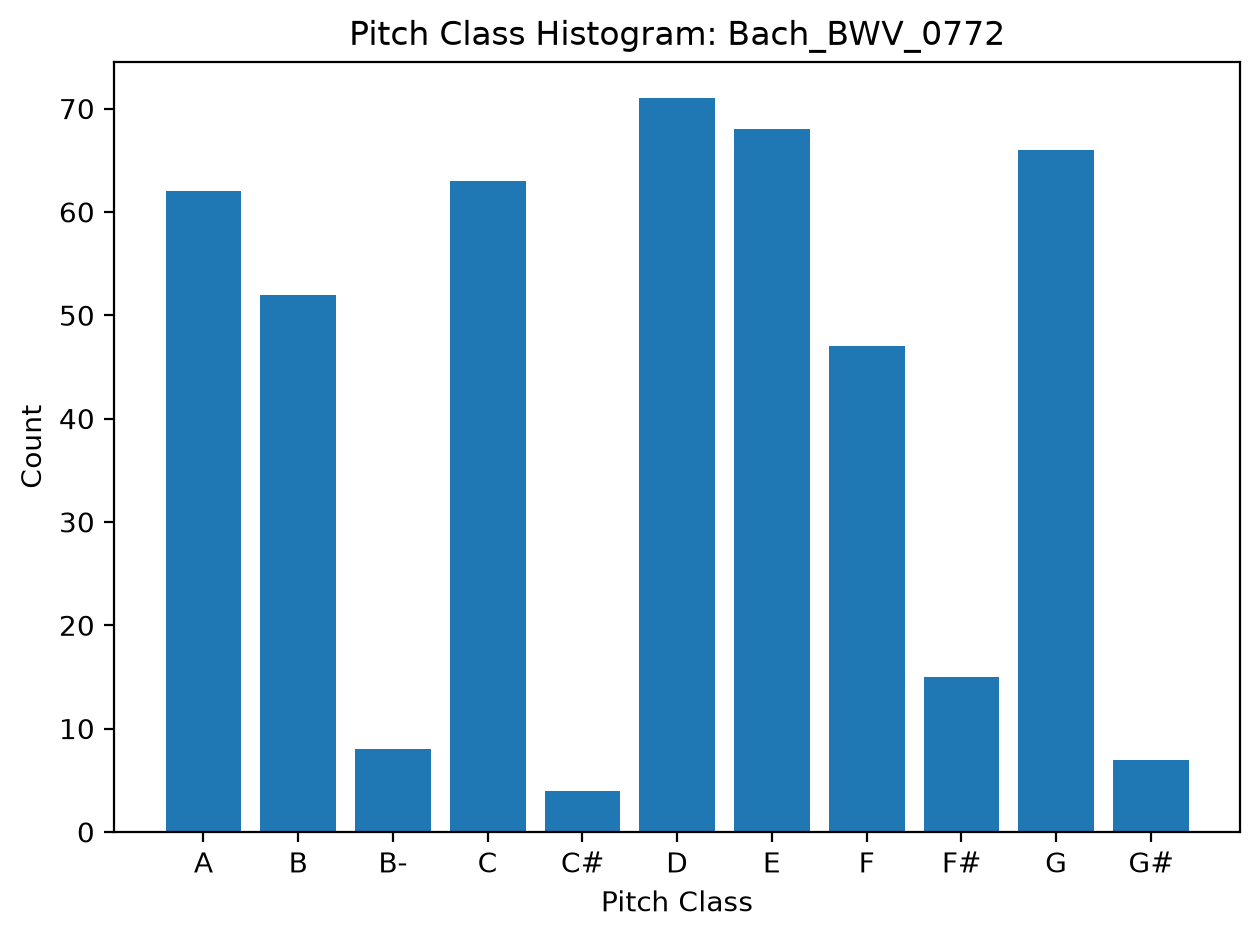

The pitch histogram for "Invention No. 1 in C major" by Johann Sebastian Bach is as follows:

- A: 62
- B: 52
- B♭: 8
- C: 63
- C♯: 4
- D: 71
- E: 68
- F: 47
- F♯: 15
- G: 66
- G♯: 7

This histogram shows how often each pitch occurs across the piece, ignoring octaves.


In [93]:
result_state = run_graph(
    histogram_question,
    "MEI Sample/Bach_BWV_0772.mei",
    use_tools=True,
)

print(result_state["answer"]) 

**LLM Without Tools:**

In [94]:
result_state = run_graph(
    histogram_question,
    "MEI Sample/Bach_BWV_0772.mei",
    use_tools=False,
)

print(result_state["answer"])

Scores chosen: ['MEI Sample/Bach_BWV_0772.mei']
To create a pitch histogram for the piece "Invention No. 1 in C major" by Johann Sebastian Bach (Bach_BWV_0772), we need to count the occurrences of each pitch class (ignoring octaves) in both parts. Here’s the process using the data provided:

1. **Combine Pitches from Both Parts:**
   - Part 1 pitches: `['C4', 'D4', 'E4', 'F4', 'D4', 'E4', 'C4', ...]`
   - Part 2 pitches: `['C3', 'D3', 'E3', 'F3', 'D3', 'E3', 'C3', ...]`

2. **Extract Pitch Classes:**
   - Convert each pitch to its pitch class (ignoring octaves). For example, `C4` and `C3` both become `C`.

3. **Count Occurrences of Each Pitch Class:**
   - Using the combined list of pitch classes, count how often each occurs.

4. **Create Histogram:**
   - Represent the counts in a histogram format.

Let's perform these steps to generate the histogram:

```plaintext
Combined Pitch List (ignoring octaves):
['C', 'D', 'E', 'F', 'D', 'E', 'C', 'G', 'C', 'B', 'C', 'D', 'G', 'A', 'B', 'C', 

**Correct Response with direct M21 Method** — the answer key, computed the same way `get_pitch_histogram()` now does internally (`count_notes_for_piece`). With the fix above, `tool_get_pitch_histogram`'s output should match this exactly.

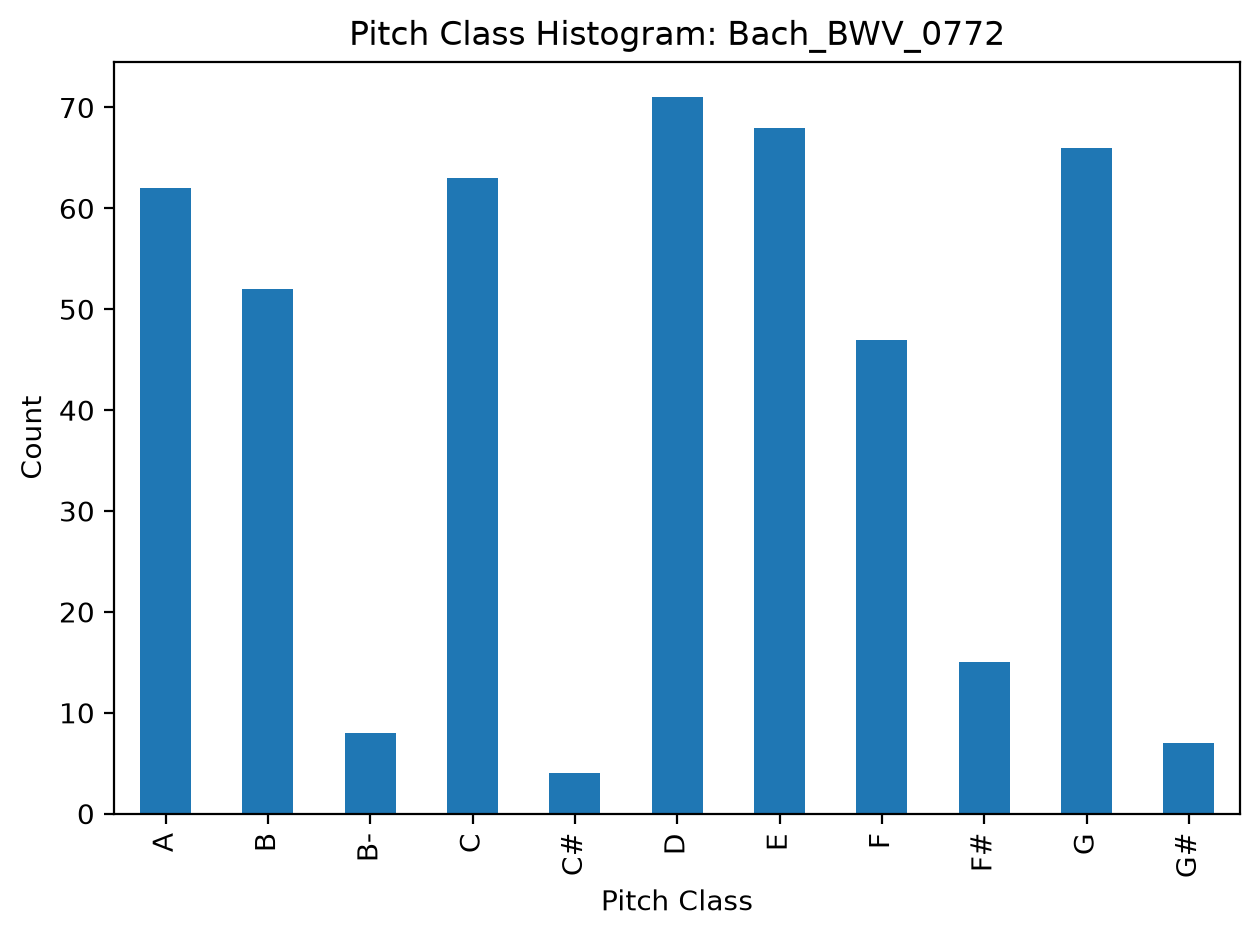

,Pitch Class,Count
0,A,62
1,B,52
2,B-,8
3,C,63
4,C#,4
5,D,71
6,E,68
7,F,47
8,F#,15
9,G,66


In [95]:
# Correct Response: pitch-class distribution computed directly, bypassing both the LLM
# and the get_pitch_histogram()/plot() path above (see note above about why).
# Plotted with matplotlib directly — the same library music21's own .plot() uses under the hood.
import matplotlib.pyplot as plt

counts = count_notes_for_piece("MEI Sample/Bach_BWV_0772.mei", pitch_with_octave=False)
df = pd.DataFrame(counts.items(), columns=["Pitch Class", "Count"])
df = df.sort_values("Pitch Class").reset_index(drop=True)

df.plot.bar(x="Pitch Class", y="Count", legend=False, title="Pitch Class Histogram: Bach_BWV_0772")
plt.xlabel("Pitch Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

df

### Lyrics: LLM with tools vs LLM vs Correct response

**Looking for Lyrics:** 

Can the LLM recover the underlying text from an MEI file, where lyrics are split across voice parts with heavy repetition?

**Important asymmetry:** `music_summaries.json` (the `all_scores` data behind `use_tools=False`) contains only pitches/intervals/keys — **no lyric text at all**. 

So the "without tools" condition below can't be run through `run_graph` the normal way; instead it loads the raw MEI XML directly and asks the plain LLM to find the lyrics in that. It's the closest fair equivalent of "no tools, no computed help" given what data is available, but keep in mind it's seeing the full file rather than a JSON summary.

In [ ]:
# Shared question — identical wording is sent to both the tools and no-tools runs
lyrics_question = "Find the lyrics in this piece of music. Don't correct any spellings or archaisms!"

**LLM With Tools:**

In [ ]:
result_state = run_graph(
    lyrics_question,
    "Morley_1595_01_Go_ye_my_canzonettes",
    use_tools=True,
)

print(result_state["answer"]) 

In [ ]:
result_state = run_graph(
    lyrics_question,
    "Morley_1595_01_Go_ye_my_canzonettes",
    use_tools=False,
)

print(result_state["answer"]) 

**Bonus / not part of the controlled comparison.** The next cell asks a differently-worded, more ambitious follow-up (reconstructing a hypothetical rhymed poem) — interesting on its own, but there's no matching "without tools" call to compare it against.

In [ ]:
result_state = run_graph(
    "Find the lyrics in this piece of music.  Can you reconstruct a hypothetical original rhyming poem from this?  Don't correct any spellings or archaisms!",
    "Morley_1595_01_Go_ye_my_canzonettes",
    use_tools=True,
)

print(result_state["answer"]) 

**LLM Without Tools:**

In [ ]:
# This bypasses run_graph/all_scores entirely: music_summaries.json has no lyrics field,
# so we give the plain LLM the raw MEI XML as context instead, using the same lyrics_question.
result = loadXML(r"MEI Sample/Morley_1595_01_Go_ye_my_canzonettes.mei").page_content

# now ask the LLM without tools!
answer = llm.invoke(
    f"""Question: {lyrics_question}
    Context: 
    {result}
    
    """
)

print(answer.content)

**Correct Response: based on direct M21 methods** — the answer key. Compare both LLM responses above against this directly-extracted text.

In [ ]:
score = converter.parse("MEI Sample/Morley_1595_01_Go_ye_my_canzonettes.mei")
lyrics = []

for n in score.recurse().notes:
    if isinstance(n, note.Note) and n.lyrics:
        for lyric in n.lyrics:
            if lyric.text:
                cleaned = lyric.text.strip().replace("\n", "").replace("\r", "")
                lyrics.append(cleaned)

formatted = " ".join(lyrics)
formatted = formatted.replace(" --", "-").replace("--", "-")
formatted = " ".join(formatted.split())
formatted = formatted.replace(",","\n")
formatted = formatted.replace(" - - ","")
print("Lyrics:\n", formatted)

### Guessing the Key: LLM with tools vs LLM vs Correct response

**Tests:** can the LLM determine a piece's key? Note there are two distinct notions of "key" tested across the cells below: the **notated key signature** (a fact you can just read) and `music21`'s **key-*finding* algorithm** (`analyze('key')`, a statistical guess from pitch content — meant to work even without a key signature). The controlled comparison pair (last cell in each subsection) asks about *all* pieces with identical wording; the earlier single-piece cells are exploratory variants with their own wording and aren't directly comparable to each other.

In [ ]:
# Shared question for the controlled comparison pair below (identical wording, all pieces)
key_question = "Guess the key of each piece. Explain why you chose each key. Return a table of piece names and keys."

**LLM With Tools** — *bonus/exploratory cells first (single piece, differently worded), controlled comparison cell last:*

In [ ]:
result_state = run_graph(
    key_question,
    "Bach_BWV_0778",
    use_tools=True,
)

print(result_state["answer"]) 

**LLM Without Tools** — *bonus/exploratory cell first (single piece, differently worded), controlled comparison cell last:*

In [ ]:
result_state = run_graph(
    key_question,
    "Bach_BWV_0778",
    use_tools=False,
)

print(result_state["answer"])

**Validate the Response!**

Run `music21` directly to get the correct answer for the key-finding algorithm. Compare both LLM responses above against this directly-computed answer.

In [55]:
# Correct Response: music21's key-finding algorithm run directly on the piece,
# bypassing the LLM entirely. Same logic as tool_analyze_key above.
piece_name = "Bach_BWV_0778"
filepath = summaries[piece_name]["mei_path"]
score = converter.parse(filepath)
key_analysis = score.analyze('key')
print(
    f"Piece: {piece_name}\n"
    f"  Key Name: {key_analysis}\n"
    f"  Confidence Factor: {key_analysis.correlationCoefficient:.4f}\n"
)

Piece: Bach_BWV_0778
  Key Name: e minor
  Confidence Factor: 0.9336



### Ranking by Difficulty: LLM with tools vs LLM vs Correct response

**Tests:** can the LLM produce a plausible difficulty ranking across all 9 pieces, and stay honest about what it did (or didn't) use to get there? There's no single objective "correct" ranking here (unlike the sections above), so this is more about comparing *reasoning quality and honesty* than a right/wrong answer.

In [56]:
# Shared question — identical wording is sent to both the tools and no-tools runs.
# Phrased to make sense in both conditions: in the no-tools condition there are no
# tools to name, so an honest answer should say so.
difficulty_question = (
    "Rank all of the musical works in our sample by difficulty. Explain your reasoning, "
    "based only on the information available to you. If you use any tools, name them specifically."
)

**LLM With Tools:**

In [57]:
result_state = run_graph(
    difficulty_question,
    use_tools=True,
)

print(result_state["answer"]) 

Scores chosen: ['Bach_BWV_0784', 'Bach_BWV_0785', 'Bach_BWV_0778', 'Bach_BWV_0779', 'Bach_BWV_0786', 'Morley_1595_08_Fire_and_ligthning', 'Morley_1595_01_Go_ye_my_canzonettes', 'Bach_BWV_0782', 'Morley_1595_02_When_lo_by_break', 'Bartok_Mikrokosmos_091', 'Bach_BWV_0783', 'Bach_BWV_0781', 'Bartok_Mikrokosmos_092', 'Bach_BWV_0780', 'Bartok_Mikrokosmos_036', 'Bartok_Mikrokosmos_022', 'Morley_1595_12_Flora_wilt_thou', 'Bartok_Mikrokosmos_023', 'Bartok_Mikrokosmos_037', 'Morley_1595_03_Sweet_nymph', 'Bartok_Mikrokosmos_035', 'Morley_1595_06_Lo_hear_another', 'Bartok_Mikrokosmos_024', 'Bartok_Mikrokosmos_030', 'Bartok_Mikrokosmos_031', 'Bartok_Mikrokosmos_025', 'Morley_1595_11_I_should_for_griefe', 'Morley_1595_05_Miraculous_loves', 'Bartok_Mikrokosmos_026', 'Bartok_Mikrokosmos_028', 'Bartok_Mikrokosmos_029', 'Bartok_Mikrokosmos_039', 'Bach_BWV_0772', 'Morley_1595_04_I_go_before', 'Morley_1595_07_Leave_now_mine_eyes', 'Bartok_Mikrokosmos_101', 'Bach_BWV_0773', 'Morley_1595_10_O_thou_that_art

**LLM Without Tools:**

In [58]:
result_state = run_graph(
    difficulty_question,
    use_tools=False,
)

print(result_state["answer"]) 

Scores chosen: ['Bach_BWV_0772', 'Bach_BWV_0778', 'Bach_BWV_0786', 'Bartok_Mikrokosmos_022', 'Bartok_Mikrokosmos_031', 'Bartok_Mikrokosmos_104', 'Morley_1595_01_Go_ye_my_canzonettes', 'Morley_1595_07_Leave_now_mine_eyes', 'Morley_1595_12_Flora_wilt_thou']
To rank the musical works in the provided sample by difficulty, I will analyze each work based on its complexity in terms of the number of notes, variety and range of pitches, intervallic structure, and other musical elements like time and key signatures. Here's my analysis:

1. **Bach_BWV_0786 (Invention No. 15 in B minor)**
   - Total number of notes is the highest among the pieces, with complex intervallic patterns and intricate melodic lines, indicative of higher difficulty.
   - Composed in B minor, the use of accidentals and modulations within the invention suggests technical and interpretative challenges.

2. **Bach_BWV_0778 (Invention No. 7 in E minor)**
   - Similar in complexity to BWV 0786, with 248 notes. Frequent modulati

There is not "correct" answer for this, but it's interesting to see the paths that it takes. It gets much more specific when run with the tools, listing each individual piece. The non-tools groups by composer. Both, for the most part, seem to agree with each other.

## Conclusions

ADD YOUR NOTES HERE

